# P9 — Satellite Anomaly Detection (IASTAM 6.0, Track 5 — Cybersecurity)
### Problem 9: "Can the Satellite Still Be Trusted?"

This notebook implements and evaluates two complementary anomaly-detection pipelines for detecting
malicious or abnormal behaviour in a space system, as requested by Problem 9 of the IASTAM 6.0
Technical Challenge.

**Pipeline A — Synthetic satellite simulator (controlled validation).**
A physically-inspired satellite telemetry simulator (thermal cycle, battery charge/discharge,
CPU/memory load, command stream, network traffic) is used to inject six families of anomalies —
four of them detectable by simple threshold rules (temperature spike, unauthorized command,
command flooding, software error burst) and two deliberately designed as **blind spots** for those
same rules (gradual sensor drift, sensor bias). This lets us *quantify exactly what a rule-based
detector misses*, and shows why a machine-learning layer is needed.

**Pipeline B — Real telemetry: the OPS-SAT-AD dataset.**
The [OPS-SAT-AD](https://github.com/kplabs-pl/OPS-SAT-AD) dataset, released by KP Labs / ESA from
the OPS-SAT nanosatellite mission, is used to benchmark nine detectors (5 unsupervised, 3
supervised, plus a proposed feature-augmented variant) on real spacecraft telemetry with expert
ground-truth anomaly labels.

**Trust-scoring layer.** On top of the best real-data detector, we simulate a per-channel *trust
score* that decays under anomalous evidence and recovers under nominal evidence, and map it to a
graduated response policy (L0 passive monitoring → L4 isolation) — directly addressing the
challenge's requirement to detect anomalies *"without necessarily interrupting the mission."*

**How to use this notebook**
1. Open in VS Code (Python + Jupyter extensions) or JupyterLab.
2. Make sure `data/dataset.csv` is present (the OPS-SAT-AD dataset; see the cell below to fetch it
   automatically if missing).
3. Run all cells top to bottom (`Run All`). Figures are displayed inline **and** saved as PNG files
   in `outputs/`, ready to drop into the pitch video or the research paper.
4. `outputs/all_results.csv` contains every metric for every detector, for the results tables in
   the paper.

| Section | Pipeline | What it produces |
|---|---|---|
| Block 1 | Setup | Imports, configuration, paths |
| Block 2 – Figure 1 | A (synthetic) | Simulator + 4-domain anomaly plot |
| Block 4 – Figure 2 | A (synthetic) | Rule / Isolation Forest / Hybrid detectors + per-family breakdown |
| Load / Train – Figure 3–7 | B (OPS-SAT-AD) | 9 detectors, ROC/PR, confusion matrices, feature importance, latency & robustness |
| Figure 8 | B (OPS-SAT-AD) | Trust scoring + graduated response |
| Figure 9–10 | B (OPS-SAT-AD) | Operational trade-off views + summary dashboard |
| Final table | Both | Consolidated metrics table for the paper |


In [39]:
# ============================================================
# BLOCK 1: IMPORTS AND CONFIGURATION
# ============================================================

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# Inline display for Jupyter. If running as .py, comment this line out.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.facecolor'] = 'white'

# ---- Paths and columns ----
DATA_PATH  = os.path.join("external", "opssat-ad", "data", "dataset.csv")  # OPS-SAT-AD dataset
OUTPUT_DIR = "outputs"  # figures + CSV results are written here
SIM_DATA_PATH = os.path.join("data", "satellite_telemetry.csv")  # synthetic dataset (Pipeline A)
os.makedirs(OUTPUT_DIR, exist_ok=True)

COL_LABEL   = 'anomaly'
COL_SPLIT   = 'train'
COL_CHANNEL = 'channel'
COL_ID      = 'segment'
META_COLS   = {COL_LABEL, COL_SPLIT, COL_CHANNEL, COL_ID, 'sampling'}

N_SIM_OBS   = 2000
N_TRAIN_SIM = 1400
N_ANOM      = 40
CONTAM      = 0.20

print("✓ Configuration ready")

✓ Configuration ready


In [40]:
# ============================================================
# OPTIONAL: fetch the OPS-SAT-AD dataset automatically if missing
# ============================================================
# The dataset is published by KP Labs / ESA at:
#   https://github.com/kplabs-pl/OPS-SAT-AD
# Expected local layout (matches this project's folder structure):
#   external/opssat-ad/data/dataset.csv

import os, shutil, subprocess

if not os.path.exists(DATA_PATH):
    print(f"{DATA_PATH} not found locally -- attempting to clone OPS-SAT-AD from GitHub...")
    try:
        os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/kplabs-pl/OPS-SAT-AD.git", "_opssat_ad_tmp"],
            check=True,
        )
        shutil.copy(os.path.join("_opssat_ad_tmp", "data", "dataset.csv"), DATA_PATH)
        shutil.rmtree("_opssat_ad_tmp", ignore_errors=True)
        print(f"\u2713 dataset.csv retrieved and placed at {DATA_PATH}")
    except Exception as e:
        print(f"\u2717 Could not fetch the dataset automatically ({e}).")
        print("  Please clone https://github.com/kplabs-pl/OPS-SAT-AD manually and copy")
        print(f"  its data/dataset.csv to {DATA_PATH}")
else:
    print(f"\u2713 dataset.csv already present at {DATA_PATH}")


✓ dataset.csv already present at external/opssat-ad/data/dataset.csv


## Pipeline A — Synthetic Satellite Simulator

**Why a synthetic pipeline at all, when we have real data?** The OPS-SAT-AD dataset (Pipeline B)
gives us realistic telemetry, but its anomalies are whatever the mission happened to experience.
To make a controlled scientific argument — *"rule-based detection has X% recall and misses exactly
these anomaly types, which is why we need ML"* — we need ground truth we fully control. The
simulator below generates 2000 timesteps (10 s cadence) of four instrument domains (thermal,
power, compute, network) plus a command stream, then injects six anomaly families with a known,
labelled ground truth. Four are rule-detectable; two (`gradual_drift`, `sensor_bias`) are
*deliberately invisible* to the four threshold rules, to demonstrate the added value of the
learning-based detector.


In [41]:
# ============================================================
# BLOCK 2: SATELLITE SIMULATOR (4 DOMAINS + 2 BLIND SPOTS)
# ============================================================

class SatelliteSimulator:
    AUTHORIZED_CMDS = ['STATUS', 'SET_MODE', 'GET_POSITION', 'REBOOT']

    def __init__(self, n_obs=2000, dt=10.0, seed=42):
        self.n_obs = n_obs
        self.dt = dt
        self.rng = np.random.RandomState(seed)

    def generate_nominal(self):
        t = np.arange(self.n_obs)
        period = 540.0
        thermal = 25.0 + 5.0*np.sin(2*np.pi*t/period) + self.rng.normal(0, 0.4, self.n_obs)
        battery = 85.0 + 8.0*np.sin(2*np.pi*t/period + np.pi) + self.rng.normal(0, 0.5, self.n_obs)
        voltage = 28.0 + self.rng.normal(0, 0.15, self.n_obs)
        current = 5.0 + self.rng.normal(0, 0.3, self.n_obs)
        cpu = np.clip(25.0 + self.rng.normal(0, 3.0, self.n_obs), 5, 60)
        mem = np.clip(40.0 + self.rng.normal(0, 4.0, self.n_obs), 20, 70)
        packets = self.rng.poisson(5.0, self.n_obs).astype(float)
        net_bytes = packets * self.rng.uniform(40, 80, self.n_obs)
        commands = self.rng.choice(self.AUTHORIZED_CMDS, self.n_obs)
        errors = self.rng.poisson(0.2, self.n_obs).astype(float)

        return pd.DataFrame({
            'temperature': thermal, 'battery': battery,
            'voltage': voltage, 'current': current,
            'cpu': cpu, 'memory': mem,
            'packet_count': packets, 'network_bytes': net_bytes,
            'command': commands, 'error_count': errors,
            'label': 0, 'anomaly_type': 'normal',
        })

    def inject_anomalies(self, df, n_anomalies=40, test_start=1400):
        """
        Inject 6 anomaly families:
          -- RULE-DETECTABLE (covered by the 4 rules) --
          - temperature_spike     (temp > 80)
          - unauthorized_command  (command not in whitelist)
          - command_flooding      (packets > 100)
          - software_error_burst  (cpu > 90)
          -- BLIND SPOTS (rules CANNOT detect) --
          - gradual_drift         (temp stays BELOW 80 but rate of change is abnormal)
          - sensor_bias           (battery/voltage offset without crossing thresholds)
        """
        df = df.copy()

        # Split anomalies: ~75% rule-detectable, ~25% blind spots
        n_rule  = n_anomalies * 6 // 8       # ~30
        n_drift = (n_anomalies - n_rule) // 2 # ~5
        n_bias  = n_anomalies - n_rule - n_drift  # ~5

        n_temp = n_rule * 3 // 8
        n_cmd  = n_rule * 3 // 8
        n_net  = n_rule * 2 // 8
        n_soft = n_rule - (n_temp + n_cmd + n_net)

        idx = np.sort(self.rng.choice(
            np.arange(test_start, self.n_obs), n_anomalies, replace=False))

        types = (['temperature_spike']     * n_temp +
                 ['unauthorized_command']  * n_cmd +
                 ['command_flooding']      * n_net +
                 ['software_error_burst']  * n_soft +
                 ['gradual_drift']         * n_drift +
                 ['sensor_bias']           * n_bias)
        self.rng.shuffle(types)

        for i, at in zip(idx, types):
            df.at[i, 'label'] = 1
            df.at[i, 'anomaly_type'] = at

            if at == 'temperature_spike':
                df.at[i, 'temperature'] = self.rng.uniform(85, 100)

            elif at == 'unauthorized_command':
                df.at[i, 'command'] = 'UNKNOWN_CMD'

            elif at == 'command_flooding':
                df.at[i, 'packet_count'] = self.rng.uniform(200, 1000)
                df.at[i, 'network_bytes'] = df.at[i, 'packet_count'] * 60

            elif at == 'software_error_burst':
                df.at[i, 'error_count'] = self.rng.uniform(20, 60)
                df.at[i, 'cpu'] = self.rng.uniform(92, 99)

            # ---- BLIND SPOTS: rules will MISS these ----
            elif at == 'gradual_drift':
                # Temperature drifts to 55-75°C -- BELOW the 80°C rule
                drift_start = max(0, i - 20)
                n_drift_pts = i - drift_start + 1
                df.loc[drift_start:i, 'temperature'] += np.linspace(
                    0, self.rng.uniform(20, 35), n_drift_pts
                )

            elif at == 'sensor_bias':
                # Battery reads ~15% below true value -- never exceeds rule bounds
                df.at[i, 'battery'] = df.at[i, 'battery'] - 15.0
                df.at[i, 'voltage'] = df.at[i, 'voltage'] - 1.5

        return df, idx


# ---- Run simulator ----
sim = SatelliteSimulator(n_obs=N_SIM_OBS, dt=10.0, seed=42)
sim_df = sim.generate_nominal()
sim_df, injected_idx = sim.inject_anomalies(sim_df, N_ANOM, N_TRAIN_SIM)

train_sim = sim_df.iloc[:N_TRAIN_SIM]
test_sim  = sim_df.iloc[N_TRAIN_SIM:]
y_sim_test = test_sim['label'].values

os.makedirs(os.path.dirname(SIM_DATA_PATH), exist_ok=True)
sim_df.to_csv(SIM_DATA_PATH, index=False)
print(f"\u2713 Synthetic dataset saved to {SIM_DATA_PATH}")

print(f"✓ Simulator ready (6 anomaly families)")
print(f"  Total   : {len(sim_df)} observations")
print(f"  Train   : {len(train_sim)} (nominal)")
print(f"  Test    : {len(test_sim)} ({y_sim_test.sum()} anomalies, "
      f"{100*y_sim_test.mean():.2f}%)")

# Count by family
family_counts = test_sim[test_sim['label']==1]['anomaly_type'].value_counts()
print(f"\n  Anomaly family breakdown:")
for fam, cnt in family_counts.items():
    print(f"    {fam:<25} {cnt}")

✓ Synthetic dataset saved to data/satellite_telemetry.csv
✓ Simulator ready (6 anomaly families)
  Total   : 2000 observations
  Train   : 1400 (nominal)
  Test    : 600 (40 anomalies, 6.67%)

  Anomaly family breakdown:
    temperature_spike         11
    unauthorized_command      11
    command_flooding          7
    gradual_drift             5
    sensor_bias               5
    software_error_burst      1


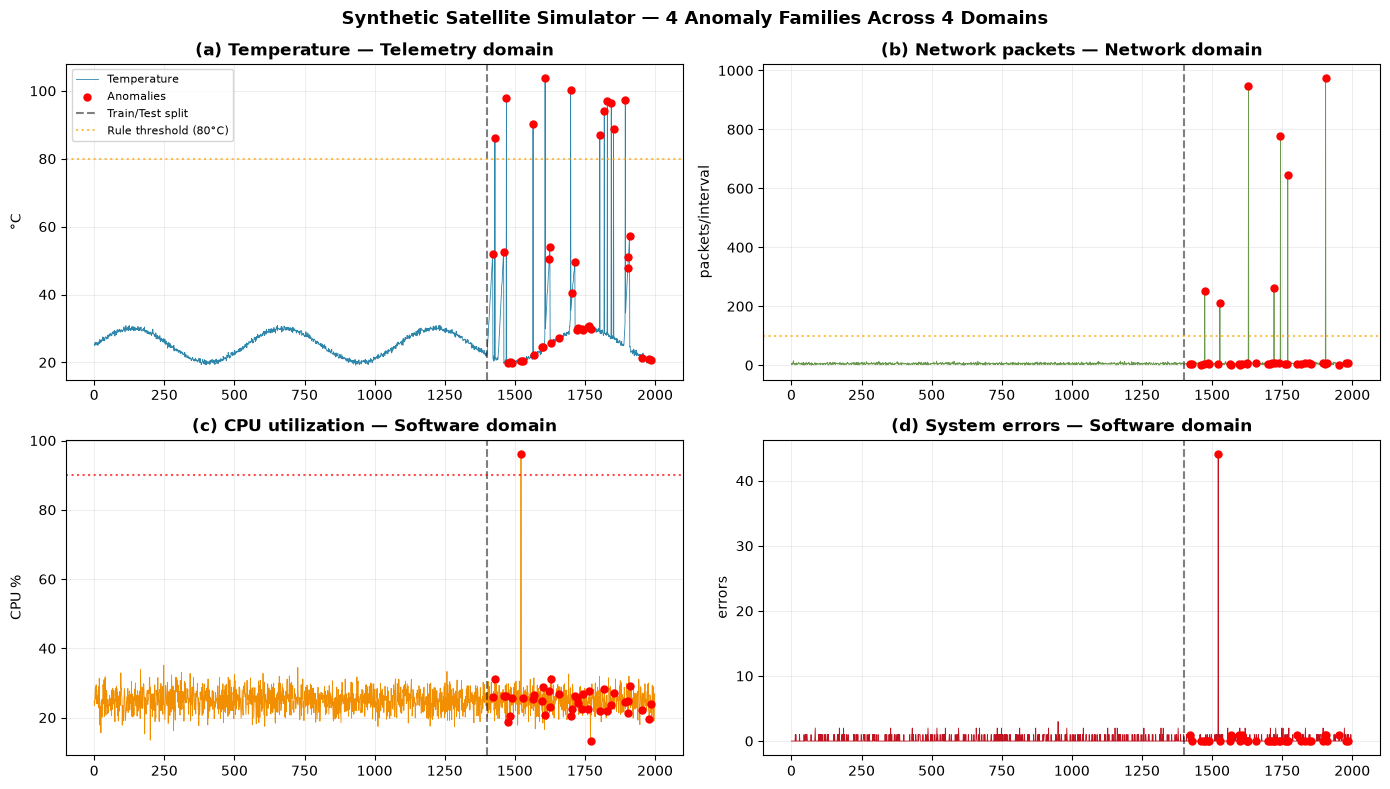

✓ Figure 1 saved


In [42]:
# ============================================================
# FIGURE 1: SIMULATOR OVERVIEW (4 ANOMALY FAMILIES)
# ============================================================

t = np.arange(len(sim_df))
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (a) Temperature
ax = axes[0, 0]
ax.plot(t, sim_df['temperature'], lw=0.6, color='#2E86AB', label='Temperature')
ax.scatter(injected_idx, sim_df.iloc[injected_idx]['temperature'],
           color='red', s=25, zorder=5, label='Anomalies')
ax.axvline(1400, color='k', ls='--', alpha=0.5, label='Train/Test split')
ax.axhline(80, color='orange', ls=':', alpha=0.7, label='Rule threshold (80°C)')
ax.set_title('(a) Temperature — Telemetry domain', fontweight='bold')
ax.set_ylabel('°C'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (b) Network packets
ax = axes[0, 1]
ax.plot(t, sim_df['packet_count'], lw=0.6, color='#6A994E')
ax.scatter(injected_idx, sim_df.iloc[injected_idx]['packet_count'],
           color='red', s=25, zorder=5)
ax.axvline(1400, color='k', ls='--', alpha=0.5)
ax.axhline(100, color='orange', ls=':', alpha=0.7)
ax.set_title('(b) Network packets — Network domain', fontweight='bold')
ax.set_ylabel('packets/interval'); ax.grid(alpha=0.3)

# (c) CPU
ax = axes[1, 0]
ax.plot(t, sim_df['cpu'], lw=0.6, color='#F18F01')
ax.scatter(injected_idx, sim_df.iloc[injected_idx]['cpu'],
           color='red', s=25, zorder=5)
ax.axvline(1400, color='k', ls='--', alpha=0.5)
ax.axhline(90, color='red', ls=':', alpha=0.7)
ax.set_title('(c) CPU utilization — Software domain', fontweight='bold')
ax.set_ylabel('CPU %'); ax.grid(alpha=0.3)

# (d) Errors
ax = axes[1, 1]
ax.plot(t, sim_df['error_count'], lw=0.6, color='#C1121F')
ax.scatter(injected_idx, sim_df.iloc[injected_idx]['error_count'],
           color='red', s=25, zorder=5)
ax.axvline(1400, color='k', ls='--', alpha=0.5)
ax.set_title('(d) System errors — Software domain', fontweight='bold')
ax.set_ylabel('errors'); ax.grid(alpha=0.3)

plt.suptitle('Synthetic Satellite Simulator — 4 Anomaly Families Across 4 Domains',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_simulator.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 1 saved")

### Detectors on the synthetic track

Three detectors are compared on the synthetic held-out test set (timesteps 1400–1999, disjoint
from the training set used to fit the Isolation Forest on nominal-only data):

1. **Rule-based** — four independent threshold rules (temperature, unauthorized command,
   packet flooding, CPU).
2. **Isolation Forest** — trained only on the 9 nominal-only engineered features (raw
   telemetry + first-order derivatives + rolling deviation from a 20-sample moving average),
   after `RobustScaler` normalisation.
3. **Hybrid** — the rule-based decision OR a *high-confidence* Isolation Forest alert (top 10%
   anomaly score on the test set), so the ML layer only overrides the rules when it is
   confident, keeping the false-positive rate in check.


In [43]:
# ============================================================
# BLOCK 4: DETECTORS ON SYNTHETIC DATA (rate-of-change features)
# ============================================================

class RuleBasedDetector:
    AUTHORIZED = set(SatelliteSimulator.AUTHORIZED_CMDS)
    def __init__(self, temp_thr=80.0, packet_thr=100.0, cpu_thr=90.0):
        self.temp_thr, self.packet_thr, self.cpu_thr = temp_thr, packet_thr, cpu_thr

    def predict(self, df):
        preds = np.zeros(len(df), dtype=int)
        reasons = []
        for i, (_, row) in enumerate(df.iterrows()):
            r = []
            if row['temperature'] > self.temp_thr: r.append('TEMP')
            if row['command'] not in self.AUTHORIZED: r.append('CMD')
            if row['packet_count'] > self.packet_thr: r.append('NET')
            if row['cpu'] > self.cpu_thr: r.append('CPU')
            if r: preds[i] = 1
            reasons.append('|'.join(r) if r else 'ok')
        return preds, reasons


def evaluate(y_true, y_pred, y_score=None, name='Model'):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp/(fp+tn) if (fp+tn) > 0 else 0.0
    mcc  = matthews_corrcoef(y_true, y_pred) if len(set(y_true)) > 1 else 0.0
    auc  = roc_auc_score(y_true, y_score) if y_score is not None and len(set(y_true)) > 1 else float('nan')
    print(f"  {name:<30} Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} "
          f"F1={f1:.3f} FPR={fpr:.3f} MCC={mcc:.3f} AUC={auc:.3f}")
    return {'name': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'fpr': fpr, 'mcc': mcc, 'auc': auc,
            'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
            'y_score': y_score}


# ---- Rule-based ----
rb = RuleBasedDetector()
y_pred_rb, _ = rb.predict(test_sim)
res_rb = evaluate(y_sim_test, y_pred_rb, name='Rule-Based (synth.)')


# ---- Feature engineering for IF ----
def build_if_features(df):
    """Add rate-of-change + rolling-deviation features."""
    feats = pd.DataFrame(index=df.index)
    feats['temperature']   = df['temperature'].values
    feats['battery']       = df['battery'].values
    feats['voltage']       = df['voltage'].values
    feats['current']       = df['current'].values
    feats['cpu']           = df['cpu'].values
    feats['memory']        = df['memory'].values
    feats['packet_count']  = df['packet_count'].values
    feats['network_bytes'] = df['network_bytes'].values
    feats['error_count']   = df['error_count'].values

    feats['temperature_diff'] = df['temperature'].diff().fillna(0).values
    feats['battery_diff']     = df['battery'].diff().fillna(0).values
    feats['voltage_diff']     = df['voltage'].diff().fillna(0).values
    feats['cpu_diff']         = df['cpu'].diff().fillna(0).values

    win = 20
    feats['temperature_dev20'] = (df['temperature'] - df['temperature'].rolling(win, min_periods=1).mean()).values
    feats['battery_dev20']     = (df['battery'] - df['battery'].rolling(win, min_periods=1).mean()).values
    feats['voltage_dev20']     = (df['voltage'] - df['voltage'].rolling(win, min_periods=1).mean()).values

    feats['cmd_unknown'] = (~df['command'].isin(SatelliteSimulator.AUTHORIZED_CMDS)).astype(int).values

    return feats.values

Xtr_sim = build_if_features(train_sim)
Xte_sim = build_if_features(test_sim)
print(f"\n  IF feature matrix: train={Xtr_sim.shape}, test={Xte_sim.shape}")

# Normalize feature scale (RobustScaler)
sc_sim = RobustScaler().fit(Xtr_sim)
Xtr_sim_s = sc_sim.transform(Xtr_sim)
Xte_sim_s = sc_sim.transform(Xte_sim)

# ---- Isolation Forest on synthetic ----
iso_sim = IsolationForest(n_estimators=100, contamination=0.05,
                           random_state=42, n_jobs=-1).fit(Xtr_sim_s)
pred_iso_sim = (iso_sim.predict(Xte_sim_s) == -1).astype(int)
score_iso_sim = -iso_sim.score_samples(Xte_sim_s)
res_iso_sim = evaluate(y_sim_test, pred_iso_sim, score_iso_sim,
                        name='Isolation Forest (synth.)')

# ---- Hybrid: rule always fires, IF only fires if highly confident ----
if_high_conf_threshold = np.percentile(score_iso_sim, 90)
pred_iso_high_conf = ((pred_iso_sim == 1) &
                       (score_iso_sim >= if_high_conf_threshold)).astype(int)
pred_hybrid = np.maximum(y_pred_rb, pred_iso_high_conf)

# >>> The missing line <<<
res_hybrid = evaluate(y_sim_test, pred_hybrid, name='Hybrid (synth.)')

# ---- Per-family detection breakdown ----
print("\n" + "=" * 70)
print("DETECTION BY ANOMALY FAMILY")
print("=" * 70)
print(f"{'Anomaly family':<25} {'N':>4} {'Rule':>6} {'IF':>6} {'Hybrid':>7}")
print("-" * 55)

breakdown = {}
for at in sorted(test_sim['anomaly_type'].unique()):
    if at == 'normal':
        continue
    mask = test_sim['anomaly_type'].values == at
    n           = int(mask.sum())
    detected_rb = int((y_pred_rb[mask] == 1).sum())
    detected_if = int((pred_iso_sim[mask] == 1).sum())
    detected_hy = int((pred_hybrid[mask] == 1).sum())
    breakdown[at] = (n, detected_rb, detected_if, detected_hy)
    marker = "  <-- blind spot" if at in ('gradual_drift', 'sensor_bias') else ""
    print(f"{at:<25} {n:>4} {detected_rb:>6} {detected_if:>6} {detected_hy:>7}{marker}")

print("-" * 55)
print(f"{'TOTAL':<25} {y_sim_test.sum():>4} "
      f"{int((y_pred_rb==1).sum()):>6} "
      f"{int((pred_iso_sim==1).sum()):>6} "
      f"{int((pred_hybrid==1).sum()):>7}")

  Rule-Based (synth.)            Acc=0.983 Prec=1.000 Rec=0.750 F1=0.857 FPR=0.000 MCC=0.858 AUC=nan

  IF feature matrix: train=(1400, 17), test=(600, 17)
  Isolation Forest (synth.)      Acc=0.860 Prec=0.238 Rec=0.500 F1=0.323 FPR=0.114 MCC=0.277 AUC=0.833
  Hybrid (synth.)                Acc=0.920 Prec=0.449 Rec=0.875 F1=0.593 FPR=0.077 MCC=0.592 AUC=nan

DETECTION BY ANOMALY FAMILY
Anomaly family               N   Rule     IF  Hybrid
-------------------------------------------------------
command_flooding             7      7      7       7
gradual_drift                5      0      0       0  <-- blind spot
sensor_bias                  5      0      5       5  <-- blind spot
software_error_burst         1      1      1       1
temperature_spike           11     11      5      11
unauthorized_command        11     11      2      11
-------------------------------------------------------
TOTAL                       40     30     84      78


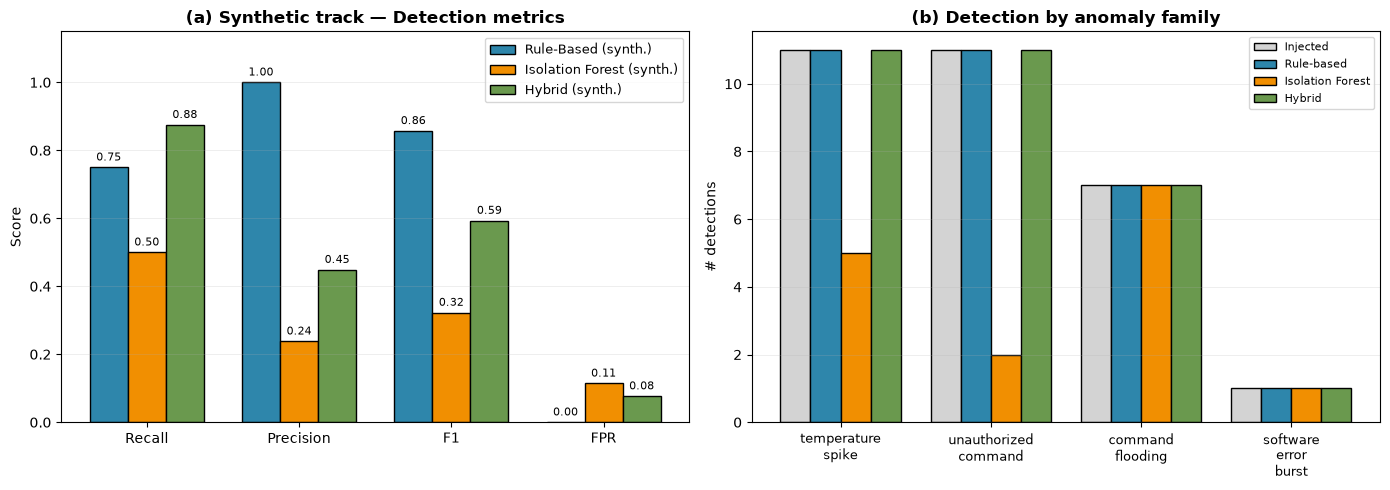

✓ Figure 2 saved


In [44]:
# ============================================================
# FIGURE 2: SYNTHETIC DETECTION PERFORMANCE
# ============================================================

synth_results = [res_rb, res_iso_sim, res_hybrid]
metrics = ['recall', 'precision', 'f1', 'fpr']
labels  = ['Recall', 'Precision', 'F1', 'FPR']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Metrics grouped bar
ax = axes[0]
x = np.arange(len(metrics))
w = 0.25
colors = ['#2E86AB', '#F18F01', '#6A994E']
for i, r in enumerate(synth_results):
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + i*w - w, vals, w, label=r['name'],
                  color=colors[i], edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{v:.2f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('(a) Synthetic track — Detection metrics', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

# (b) Anomaly-type breakdown
ax = axes[1]
breakdown = {'temperature_spike': [], 'unauthorized_command': [],
             'command_flooding': [], 'software_error_burst': []}
for at in breakdown:
    mask = test_sim['anomaly_type'].values == at
    n = mask.sum()
    detected_rb = int((y_pred_rb[mask] == 1).sum()) if n else 0
    detected_if = int((pred_iso_sim[mask] == 1).sum()) if n else 0
    detected_hy = int((pred_hybrid[mask] == 1).sum()) if n else 0
    breakdown[at] = [n, detected_rb, detected_if, detected_hy]

labels_bb = list(breakdown.keys())
x = np.arange(len(labels_bb))
w = 0.2
ax.bar(x - 1.5*w, [breakdown[k][0] for k in labels_bb], w,
       label='Injected', color='lightgray', edgecolor='black')
ax.bar(x - 0.5*w, [breakdown[k][1] for k in labels_bb], w,
       label='Rule-based', color='#2E86AB', edgecolor='black')
ax.bar(x + 0.5*w, [breakdown[k][2] for k in labels_bb], w,
       label='Isolation Forest', color='#F18F01', edgecolor='black')
ax.bar(x + 1.5*w, [breakdown[k][3] for k in labels_bb], w,
       label='Hybrid', color='#6A994E', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels([k.replace('_', '\n') for k in labels_bb], fontsize=9)
ax.set_ylabel('# detections')
ax.set_title('(b) Detection by anomaly family', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_synthetic_results.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved")

## Pipeline B — Real Telemetry: OPS-SAT-AD

We now switch to the [OPS-SAT-AD](https://github.com/kplabs-pl/OPS-SAT-AD) dataset: 2123 telemetry
*segments* extracted from the OPS-SAT nanosatellite, each summarised by 18 statistical/shape
features (`duration`, `mean`, `var`, `kurtosis`, `n_peaks`, ...), with an official chronological
train/test split (`train` column) and expert-labelled ground truth (`anomaly` column). This is the
benchmark referenced in the IASTAM reading list (*"Advancing Earth Observation..."*, and multiple
onboard-AI / cybersecurity references).

Nine detectors are trained and evaluated on the identical official test split:
- **5 unsupervised** (trained on nominal-only training data): Isolation Forest, One-Class SVM,
  Local Outlier Factor, Elliptic Envelope (with PCA pre-processing), and a simple 3-sigma
  per-feature outlier rule.
- **3 supervised** (trained on all labelled training data): Random Forest, Logistic Regression,
  MLP.
- **1 proposed variant, RF + CDCG**: Random Forest trained on the original 18 features *plus* four
  new **Channel-conditioned Deviation / Cross-channel Gap (CDCG)** features that compare each
  segment against both the global and the *per-channel* nominal distribution — motivated by the
  fact that "normal" varies a lot between telemetry channels, so a global threshold under- or
  over-reacts depending on the channel.


In [45]:
# ============================================================
# LOAD OPSSAT-AD
# ============================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"✓ OPSSAT-AD loaded: {df.shape}")

feature_cols = [c for c in df.columns
                if c not in META_COLS
                and df[c].dtype in (np.float64, np.float32, np.int64, np.int32)]
print(f"  Features: {len(feature_cols)}")

train_df = df[df[COL_SPLIT] == 1].copy()
test_df  = df[df[COL_SPLIT] == 0].copy()
y_train = train_df[COL_LABEL].values
y_test  = test_df[COL_LABEL].values

print(f"  Train: {len(train_df)} ({int(y_train.sum())} anomalous)")
print(f"  Test : {len(test_df)}  ({int(y_test.sum())} anomalous)")

# Scaling
scaler = RobustScaler()
X_train_all = scaler.fit_transform(train_df[feature_cols].values)
X_test_all  = scaler.transform(test_df[feature_cols].values)
X_train_normal = X_train_all[y_train == 0]
print(f"  Normal-only training subset: {X_train_normal.shape}")

✓ OPSSAT-AD loaded: (2123, 23)
  Features: 18
  Train: 1594 (321 anomalous)
  Test : 529  (113 anomalous)
  Normal-only training subset: (1273, 18)


> **Why include supervised models (Random Forest, Logistic Regression, MLP) in an "anomaly
> detection" comparison?**
>
> OPS-SAT-AD provides expert ground-truth labels, so nothing prevents training a supervised
> classifier on it — and in practice it gives the strongest raw scores (see results below). But
> this comes with an important caveat for a cybersecurity setting: **a supervised model only
> recognises anomaly types it has already seen during training.** A genuinely novel attack (a
> zero-day command injection, an attack pattern never observed before) will *not* trigger a
> supervised classifier trained without examples of it, whereas an **unsupervised** detector
> (Isolation Forest, LOF, ...) only needs a model of "normal" and will flag *any* sufficiently
> large deviation from it — including attacks it has never seen.
>
> **Practical takeaway for the system design:** supervised models give an *upper bound* on
> achievable performance against known threats; unsupervised models are the realistic first line
> of defence against unknown ones. Our final design (`RF + CDCG` for known patterns, backed by the
> trust-scoring layer, which reacts to *any* sustained anomalous evidence regardless of its
> label) is intended to cover both cases rather than picking one family exclusively.


In [46]:
# ============================================================
# TRAIN ALL DETECTORS ON OPSSAT-AD
# ============================================================

print("\n--- Unsupervised detectors (fit on normal-only) ---")

# Isolation Forest
if_ = IsolationForest(n_estimators=100, contamination=CONTAM,
                       random_state=42, n_jobs=-1).fit(X_train_normal)
pred_if = (if_.predict(X_test_all) == -1).astype(int)
score_if = -if_.score_samples(X_test_all)
res_if = evaluate(y_test, pred_if, score_if, 'Isolation Forest')

# One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', nu=CONTAM, gamma='scale').fit(X_train_normal)
pred_ocsvm = (ocsvm.predict(X_test_all) == -1).astype(int)
score_ocsvm = -ocsvm.decision_function(X_test_all)
res_ocsvm = evaluate(y_test, pred_ocsvm, score_ocsvm, 'One-Class SVM')

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAM,
                          novelty=True).fit(X_train_normal)
pred_lof = (lof.predict(X_test_all) == -1).astype(int)
score_lof = -lof.decision_function(X_test_all)
res_lof = evaluate(y_test, pred_lof, score_lof, 'Local Outlier Factor')

# Elliptic Envelope (with PCA pre-processing)
pca = PCA(n_components=8, random_state=42).fit(X_train_normal)
ee = EllipticEnvelope(contamination=CONTAM, random_state=42).fit(
    pca.transform(X_train_normal))
pred_ee = (ee.predict(pca.transform(X_test_all)) == -1).astype(int)
score_ee = -ee.decision_function(pca.transform(X_test_all))
res_ee = evaluate(y_test, pred_ee, score_ee, 'Elliptic Envelope (PCA)')

# 3-Sigma
mu = X_train_normal.mean(axis=0)
sigma = X_train_normal.std(axis=0) + 1e-9
z_max = np.max(np.abs((X_test_all - mu) / sigma), axis=1)
pred_3sig = (z_max > 3.0).astype(int)
res_3sig = evaluate(y_test, pred_3sig, z_max, '3-Sigma')

print("\n--- Supervised detectors (fit on all labeled) ---")

rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             random_state=42, n_jobs=-1).fit(X_train_all, y_train)
pred_rf = rf.predict(X_test_all); score_rf = rf.predict_proba(X_test_all)[:,1]
res_rf = evaluate(y_test, pred_rf, score_rf, 'Random Forest')

lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_all, y_train)
pred_lr = lr.predict(X_test_all); score_lr = lr.predict_proba(X_test_all)[:,1]
res_lr = evaluate(y_test, pred_lr, score_lr, 'Logistic Regression')

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500,
                     random_state=42, early_stopping=True).fit(X_train_all, y_train)
pred_mlp = mlp.predict(X_test_all); score_mlp = mlp.predict_proba(X_test_all)[:,1]
res_mlp = evaluate(y_test, pred_mlp, score_mlp, 'MLP')


--- Unsupervised detectors (fit on normal-only) ---
  Isolation Forest               Acc=0.718 Prec=0.373 Rec=0.469 F1=0.416 FPR=0.214 MCC=0.236 AUC=0.698
  One-Class SVM                  Acc=0.743 Prec=0.416 Rec=0.504 F1=0.456 FPR=0.192 MCC=0.292 AUC=0.693
  Local Outlier Factor           Acc=0.854 Prec=0.597 Rec=0.982 F1=0.742 FPR=0.180 MCC=0.688 AUC=0.978
  Elliptic Envelope (PCA)        Acc=0.713 Prec=0.353 Rec=0.416 F1=0.382 FPR=0.207 MCC=0.198 AUC=0.762
  3-Sigma                        Acc=0.820 Prec=0.568 Rec=0.664 F1=0.612 FPR=0.137 MCC=0.499 AUC=0.781

--- Supervised detectors (fit on all labeled) ---
  Random Forest                  Acc=0.966 Prec=0.970 Rec=0.867 F1=0.916 FPR=0.007 MCC=0.897 AUC=0.988
  Logistic Regression            Acc=0.922 Prec=0.909 Rec=0.708 F1=0.796 FPR=0.019 MCC=0.758 AUC=0.969
  MLP                            Acc=0.940 Prec=0.945 Rec=0.761 F1=0.843 FPR=0.012 MCC=0.813 AUC=0.984


In [47]:
# ============================================================
# CDCG FEATURE AUGMENTATION
# ============================================================

def add_cdcg_features(train_df, test_df, feature_cols, channel_col):
    channel_means = train_df.groupby(channel_col)[feature_cols].mean()
    global_mean = train_df[feature_cols].mean()
    global_std  = train_df[feature_cols].std() + 1e-9

    def augment(df):
        out = df.copy()
        feats = df[feature_cols].values

        z_g = (feats - global_mean.values) / global_std.values
        out['cdcg_dev_global'] = np.max(np.abs(z_g), axis=1)

        ch_mean_list = []
        for ch in df[channel_col].values:
            if ch in channel_means.index:
                ch_mean_list.append(channel_means.loc[ch].values)
            else:
                ch_mean_list.append(global_mean.values)
        ch_mean_arr = np.stack(ch_mean_list)

        z_c = (feats - ch_mean_arr) / global_std.values
        out['cdcg_dev_channel'] = np.max(np.abs(z_c), axis=1)
        out['cdcg_n_deviant']   = (np.abs(z_c) > 2.0).sum(axis=1)
        norms = np.linalg.norm(z_c, axis=1) + 1e-9
        out['cdcg_cos_channel'] = (z_c * (z_c / norms[:, None])).sum(axis=1)
        return out

    train_aug = augment(train_df)
    test_aug  = augment(test_df)
    cdcg_cols = ['cdcg_dev_global','cdcg_dev_channel',
                 'cdcg_n_deviant','cdcg_cos_channel']
    return train_aug, test_aug, feature_cols + cdcg_cols, cdcg_cols


train_aug, test_aug, aug_cols, cdcg_cols = add_cdcg_features(
    train_df, test_df, feature_cols, COL_CHANNEL)
scaler_aug = RobustScaler().fit(train_aug[aug_cols].values)
X_train_aug = scaler_aug.transform(train_aug[aug_cols].values)
X_test_aug  = scaler_aug.transform(test_aug[aug_cols].values)

rf_cdcg = RandomForestClassifier(n_estimators=200, max_depth=12,
                                  random_state=42, n_jobs=-1).fit(
    X_train_aug, y_train)
pred_cdcg = rf_cdcg.predict(X_test_aug)
score_cdcg = rf_cdcg.predict_proba(X_test_aug)[:,1]
res_cdcg = evaluate(y_test, pred_cdcg, score_cdcg, 'RF + CDCG')

  RF + CDCG                      Acc=0.968 Prec=0.980 Rec=0.867 F1=0.920 FPR=0.005 MCC=0.903 AUC=0.990


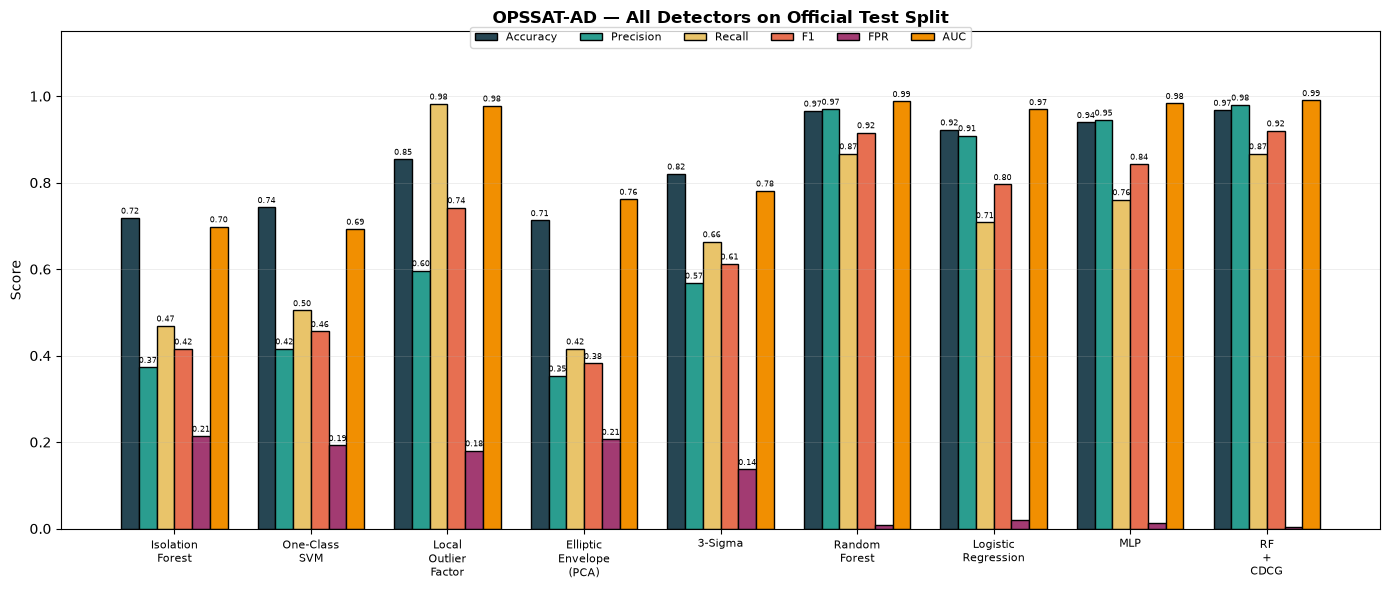

✓ Figure 3 saved


In [48]:
# ============================================================
# FIGURE 3: OPSSAT-AD FULL COMPARISON
# ============================================================

real_results = [res_if, res_ocsvm, res_lof, res_ee, res_3sig,
                res_rf, res_lr, res_mlp, res_cdcg]

fig, ax = plt.subplots(figsize=(14, 6))
metrics = ['accuracy','precision','recall','f1','fpr','auc']
metric_labels = ['Accuracy','Precision','Recall','F1','FPR','AUC']
x = np.arange(len(real_results))
width = 0.13
metric_colors = ['#264653','#2A9D8F','#E9C46A','#E76F51','#A23B72','#F18F01']

for i, (m, lab, c) in enumerate(zip(metrics, metric_labels, metric_colors)):
    vals = [r[m] if not np.isnan(r[m]) else 0 for r in real_results]
    bars = ax.bar(x + i*width - 2.5*width, vals, width,
                   label=lab, color=c, edgecolor='black')
    for bar, v in zip(bars, vals):
        if v > 0.05:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.2f}', ha='center', fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels([r['name'].replace(' ', '\n') for r in real_results],
                    rotation=0, ha='center', fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('OPSSAT-AD — All Detectors on Official Test Split',
             fontweight='bold')
ax.legend(fontsize=8, ncol=6, loc='upper center',
          bbox_to_anchor=(0.5, 1.02))
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_opssat_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")

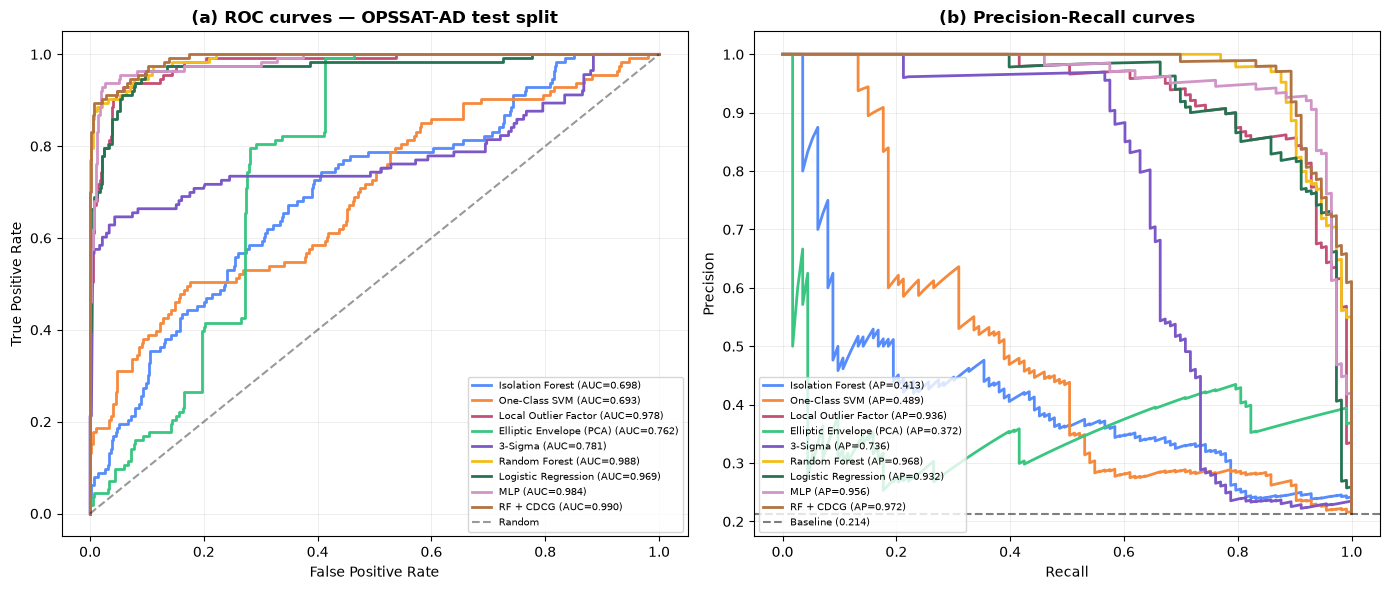

✓ Figure 4 saved


In [49]:
# ============================================================
# FIGURE 4: ROC + PR CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) ROC
ax = axes[0]
for r in real_results:
    if r['y_score'] is not None and not np.isnan(r['auc']):
        fpr_c, tpr_c, _ = roc_curve(y_test, r['y_score'])
        ax.plot(fpr_c, tpr_c, linewidth=2,
                label=f"{r['name']} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('(a) ROC curves — OPSSAT-AD test split', fontweight='bold')
ax.legend(fontsize=7, loc='lower right')
ax.grid(alpha=0.3)

# (b) PR
ax = axes[1]
for r in real_results:
    if r['y_score'] is not None:
        p_c, rec_c, _ = precision_recall_curve(y_test, r['y_score'])
        ap = average_precision_score(y_test, r['y_score'])
        ax.plot(rec_c, p_c, linewidth=2,
                label=f"{r['name']} (AP={ap:.3f})")
ax.axhline(y_test.mean(), color='k', ls='--', alpha=0.5,
            label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('(b) Precision-Recall curves', fontweight='bold')
ax.legend(fontsize=7, loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_roc_pr.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved")

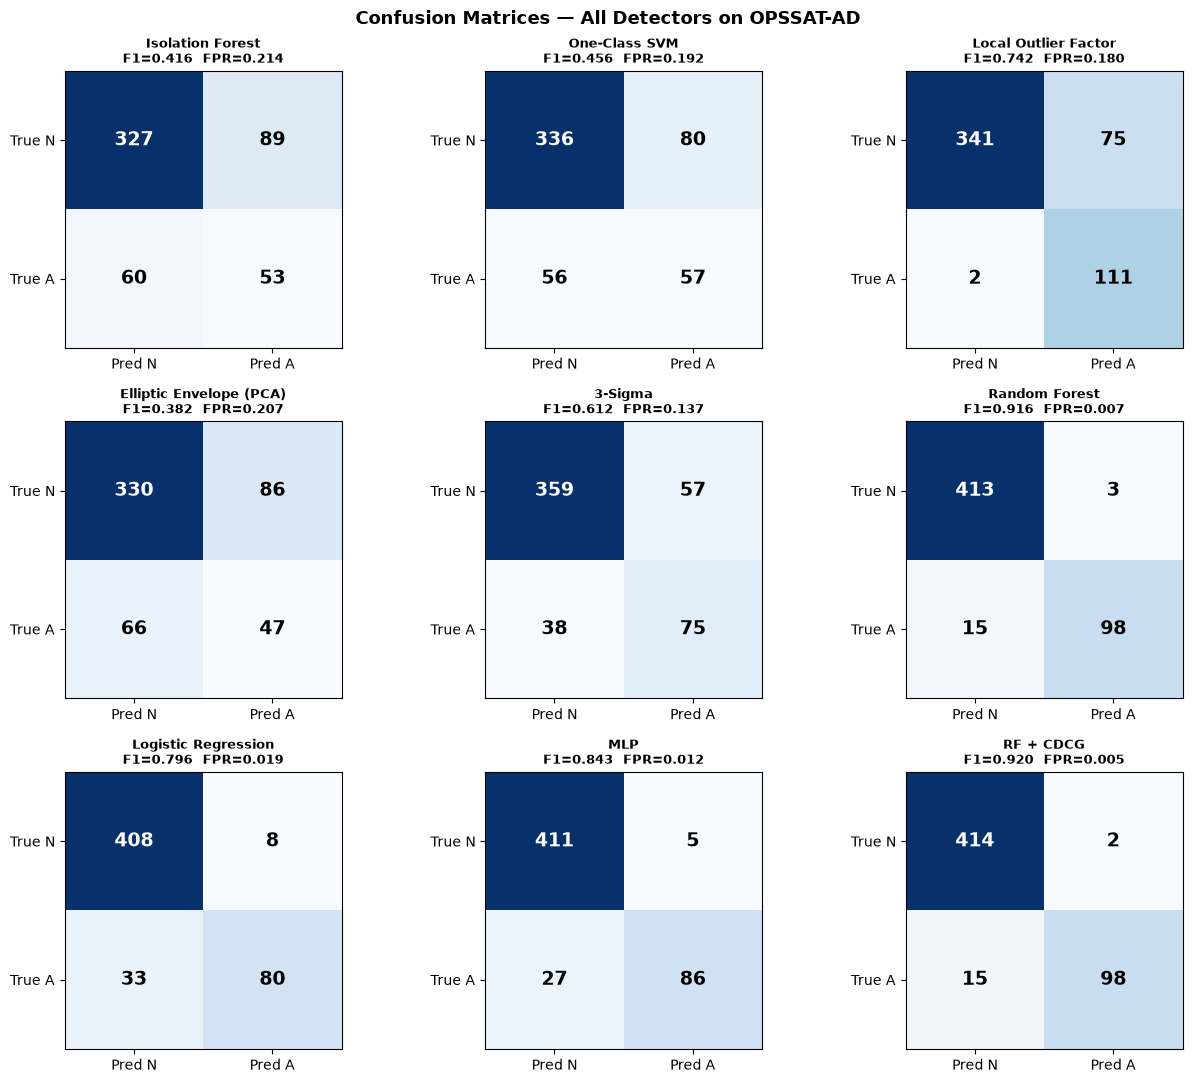

✓ Figure 5 saved


In [50]:
# ============================================================
# FIGURE 5: CONFUSION MATRICES (ALL DETECTORS)
# ============================================================

all_results = [res_if, res_ocsvm, res_lof, res_ee, res_3sig,
               res_rf, res_lr, res_mlp, res_cdcg]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for ax, r in zip(axes.flatten(), all_results):
    cm = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            color = 'white' if v > cm.max()/2 else 'black'
            ax.text(j, i, str(v), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred N','Pred A'])
    ax.set_yticklabels(['True N','True A'])
    ax.set_title(f"{r['name']}\nF1={r['f1']:.3f}  FPR={r['fpr']:.3f}",
                 fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrices — All Detectors on OPSSAT-AD',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig5_confusion_matrices.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 5 saved")

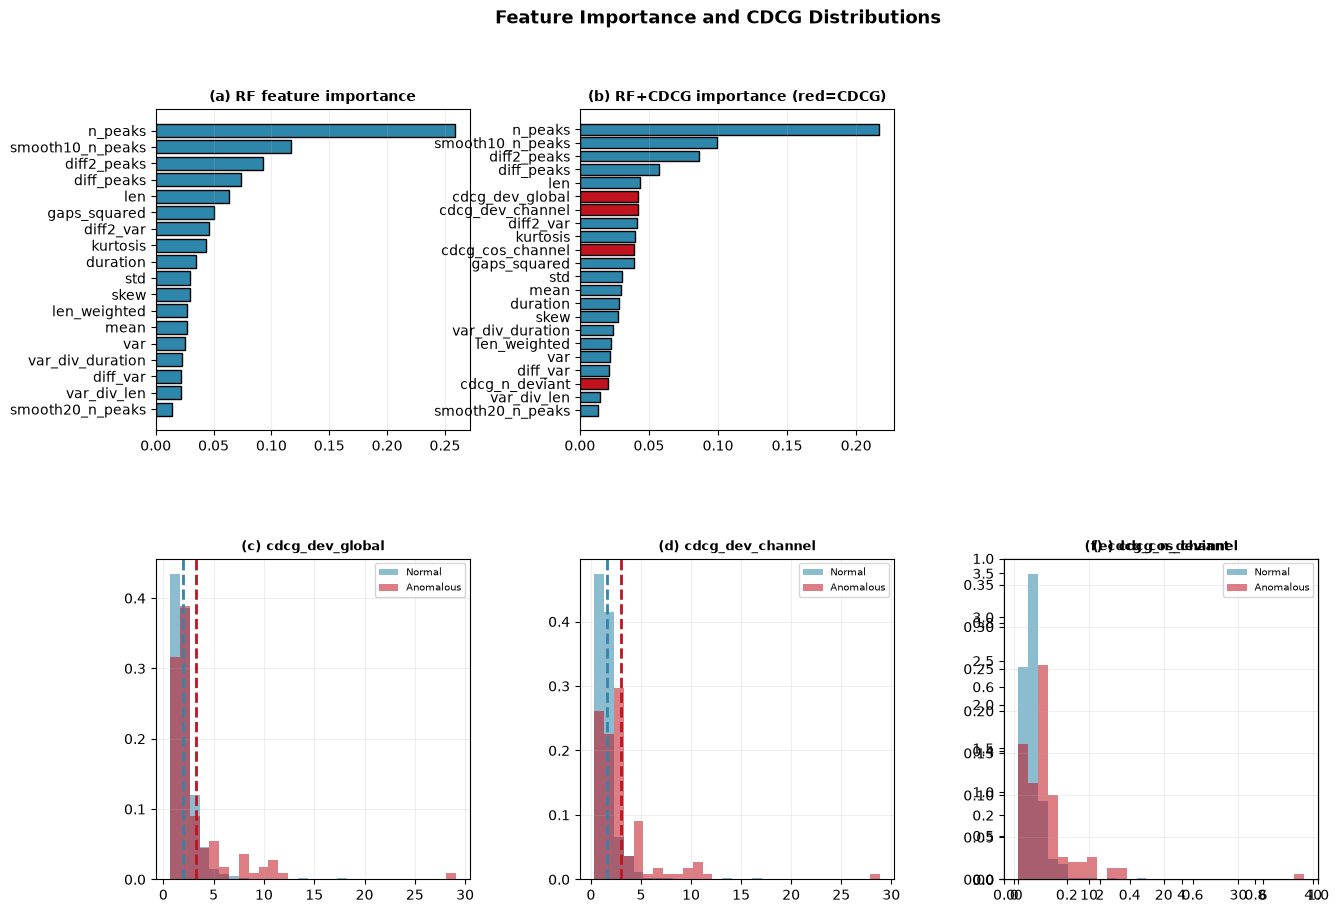

✓ Figure 6 saved


In [51]:
# ============================================================
# FIGURE 6: FEATURE IMPORTANCE + CDCG DISTRIBUTIONS
# ============================================================

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# (a) RF importance
ax = fig.add_subplot(gs[0, 0])
imp = rf.feature_importances_
idx = np.argsort(imp)[::-1]
ax.barh([feature_cols[i] for i in idx], imp[idx],
         color='#2E86AB', edgecolor='black')
ax.invert_yaxis()
ax.set_title('(a) RF feature importance', fontweight='bold', fontsize=10)
ax.grid(alpha=0.3, axis='x')

# (b) RF+CDCG importance
ax = fig.add_subplot(gs[0, 1])
imp2 = rf_cdcg.feature_importances_
idx2 = np.argsort(imp2)[::-1]
colors2 = ['#C1121F' if aug_cols[i] in cdcg_cols else '#2E86AB' for i in idx2]
ax.barh([aug_cols[i] for i in idx2], imp2[idx2],
         color=colors2, edgecolor='black')
ax.invert_yaxis()
ax.set_title('(b) RF+CDCG importance (red=CDCG)',
             fontweight='bold', fontsize=10)
ax.grid(alpha=0.3, axis='x')

# (c)-(f): CDCG distributions
for i, col in enumerate(cdcg_cols):
    ax = fig.add_subplot(gs[1, i if i < 3 else 2])
    if i >= 3:
        break
    normal_vals = test_aug.loc[test_aug[COL_LABEL]==0, col].values
    anom_vals   = test_aug.loc[test_aug[COL_LABEL]==1, col].values
    bins = np.linspace(min(normal_vals.min(), anom_vals.min()),
                        max(normal_vals.max(), anom_vals.max()), 30)
    ax.hist(normal_vals, bins=bins, alpha=0.55, color='#2E86AB',
            label='Normal', density=True)
    ax.hist(anom_vals, bins=bins, alpha=0.55, color='#C1121F',
            label='Anomalous', density=True)
    ax.axvline(normal_vals.mean(), color='#2E86AB', ls='--', lw=2)
    ax.axvline(anom_vals.mean(), color='#C1121F', ls='--', lw=2)
    ax.set_title(f'({chr(99+i)}) {col}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (f) Extra CDCG feature
ax = fig.add_subplot(gs[1, 2])
col = cdcg_cols[-1]
normal_vals = test_aug.loc[test_aug[COL_LABEL]==0, col].values
anom_vals   = test_aug.loc[test_aug[COL_LABEL]==1, col].values
bins = np.linspace(min(normal_vals.min(), anom_vals.min()),
                    max(normal_vals.max(), anom_vals.max()), 30)
ax.hist(normal_vals, bins=bins, alpha=0.55, color='#2E86AB',
        label='Normal', density=True)
ax.hist(anom_vals, bins=bins, alpha=0.55, color='#C1121F',
        label='Anomalous', density=True)
ax.set_title(f'(f) {col}', fontweight='bold', fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('Feature Importance and CDCG Distributions',
             fontsize=13, fontweight='bold', y=0.98)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig6_importance_cdcg.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 6 saved")

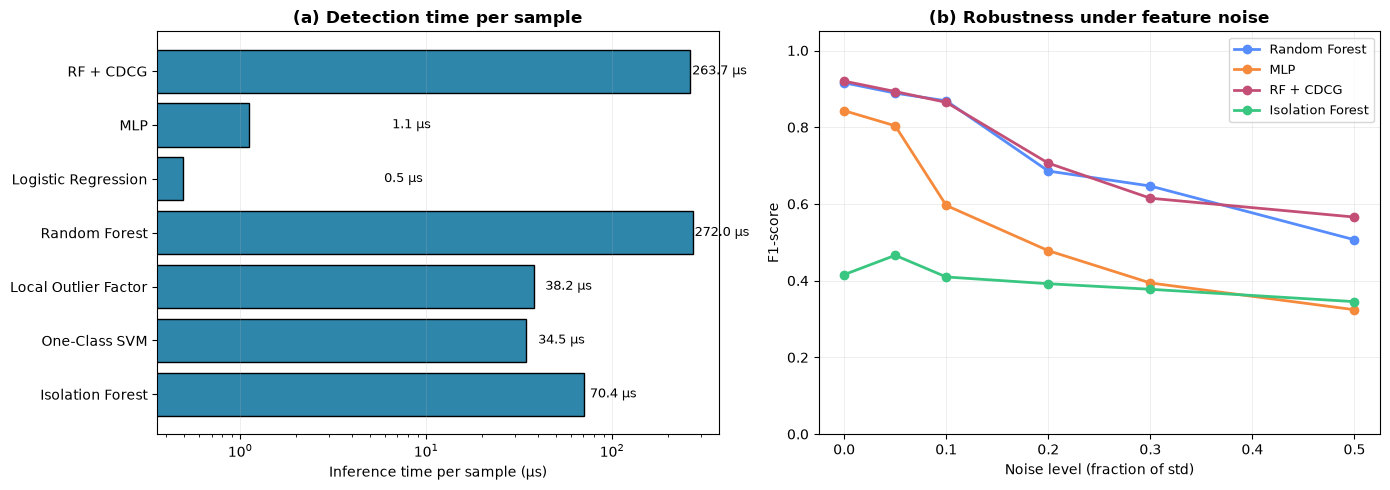

✓ Figure 7 saved

Detection times (µs/sample):
  Isolation Forest            70.39
  One-Class SVM               34.50
  Local Outlier Factor        38.20
  Random Forest              272.05
  Logistic Regression          0.49
  MLP                          1.11
  RF + CDCG                  263.68


In [52]:
# ============================================================
# FIGURE 7: DETECTION TIME + ROBUSTNESS
# ============================================================

def measure_latency(model, X, n_repeats=20):
    _ = model.predict(X)
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        _ = model.predict(X)
    t1 = time.perf_counter()
    return (t1 - t0) / n_repeats / len(X) * 1e6

latencies = {
    'Isolation Forest': measure_latency(if_, X_test_all),
    'One-Class SVM': measure_latency(ocsvm, X_test_all),
    'Local Outlier Factor': measure_latency(lof, X_test_all),
    'Random Forest': measure_latency(rf, X_test_all),
    'Logistic Regression': measure_latency(lr, X_test_all),
    'MLP': measure_latency(mlp, X_test_all),
    'RF + CDCG': measure_latency(rf_cdcg, X_test_aug),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Detection time bar chart
ax = axes[0]
names = list(latencies.keys())
vals = list(latencies.values())
bars = ax.barh(names, vals, color='#2E86AB', edgecolor='black')
for bar, v in zip(bars, vals):
    ax.text(bar.get_width()+max(vals)*0.02,
            bar.get_y()+bar.get_height()/2, f'{v:.1f} µs',
            va='center', fontsize=9)
ax.set_xlabel('Inference time per sample (µs)')
ax.set_xscale('log')
ax.set_title('(a) Detection time per sample', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# (b) Robustness under noise
ax = axes[1]
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]
models_for_noise = [
    ('Random Forest', rf, X_test_all, 'sup'),
    ('MLP', mlp, X_test_all, 'sup'),
    ('RF + CDCG', rf_cdcg, X_test_aug, 'sup'),
    ('Isolation Forest', if_, X_test_all, 'unsup'),
]
rng = np.random.RandomState(42)
for name, model, X, kind in models_for_noise:
    f1s = []
    for s in noise_levels:
        Xn = X + rng.normal(0, s, X.shape) * np.std(X, axis=0)
        if kind == 'unsup':
            preds = (model.predict(Xn) == -1).astype(int)
        else:
            preds = model.predict(Xn)
        f1s.append(f1_score(y_test, preds, zero_division=0))
    ax.plot(noise_levels, f1s, marker='o', linewidth=2, label=name)
ax.set_xlabel('Noise level (fraction of std)')
ax.set_ylabel('F1-score')
ax.set_title('(b) Robustness under feature noise', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig7_time_robustness.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 7 saved")
print("\nDetection times (µs/sample):")
for k, v in latencies.items():
    print(f"  {k:<24} {v:>8.2f}")

### Trust scoring and graduated response

Problem 9 explicitly asks for anomalies to be detected **"without necessarily interrupting the
mission."** A binary anomaly flag is a blunt instrument: a single false positive would either be
ignored (useless) or trigger a costly safe-mode (dangerous). Instead, we maintain a **per-channel
trust score** in `[0, 1]` that decays proportionally to the anomaly score when evidence is
anomalous, and slowly recovers when evidence is nominal (an exponentially-weighted trust filter).
The trust score is then mapped to a **five-level graduated response** (L0 passive monitoring → L4
isolation), so the system's reaction is proportional to sustained evidence rather than to any
single noisy sample.


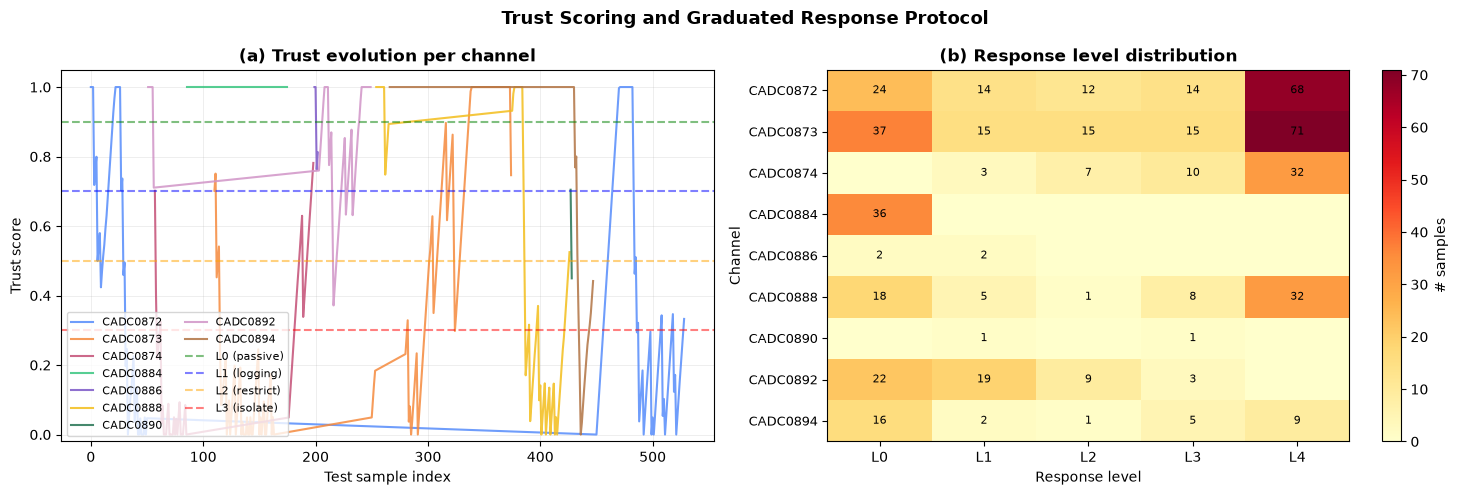

✓ Figure 8 saved

Final trust scores:
  CADC0872      0.3327  Level 3
  CADC0873      0.7464  Level 1
  CADC0874      0.7816  Level 1
  CADC0884      1.0000  Level 0
  CADC0886      0.8116  Level 1
  CADC0888      0.5249  Level 2
  CADC0890      0.4495  Level 3
  CADC0892      1.0000  Level 0
  CADC0894      0.4418  Level 3


In [53]:
# ============================================================
# FIGURE 8: TRUST SCORING + GRADUATED RESPONSE
# ============================================================

# Trust scoring simulation
alpha_t, beta_t, thresh_t = 0.05, 0.30, 0.5
trust_scores = {}
trust_traces = {}
timesteps_ch = {}

test_channels = test_df[COL_CHANNEL].values
unique_channels = sorted(set(test_channels))

for ch in unique_channels:
    trust_scores[ch] = 1.0
    trust_traces[ch] = []
    timesteps_ch[ch] = []

for i, (s, ch) in enumerate(zip(score_cdcg, test_channels)):
    t = trust_scores[ch]
    if s > thresh_t:
        t_new = t - beta_t * s
    else:
        t_new = t + alpha_t * (1 - s)
    t_new = float(np.clip(t_new, 0, 1))
    trust_scores[ch] = t_new
    trust_traces[ch].append(t_new)
    timesteps_ch[ch].append(i)

def trust_to_level(t):
    if t > 0.9: return 0
    if t > 0.7: return 1
    if t > 0.5: return 2
    if t > 0.3: return 3
    return 4

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Trust evolution per channel
ax = axes[0]
for ch in unique_channels:
    ax.plot(timesteps_ch[ch], trust_traces[ch],
            label=ch, linewidth=1.5, alpha=0.85)
ax.axhline(0.9, color='green', ls='--', alpha=0.5, label='L0 (passive)')
ax.axhline(0.7, color='blue', ls='--', alpha=0.5, label='L1 (logging)')
ax.axhline(0.5, color='orange', ls='--', alpha=0.5, label='L2 (restrict)')
ax.axhline(0.3, color='red', ls='--', alpha=0.5, label='L3 (isolate)')
ax.set_xlabel('Test sample index')
ax.set_ylabel('Trust score')
ax.set_title('(a) Trust evolution per channel', fontweight='bold')
ax.legend(fontsize=8, loc='lower left', ncol=2)
ax.grid(alpha=0.3)
ax.set_ylim(-0.02, 1.05)

# (b) Final response level + heatmap
ax = axes[1]
level_matrix = np.zeros((len(unique_channels), 5))
for ch in unique_channels:
    for t in trust_traces[ch]:
        level_matrix[unique_channels.index(ch), trust_to_level(t)] += 1

im = ax.imshow(level_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(5))
ax.set_xticklabels(['L0','L1','L2','L3','L4'])
ax.set_yticks(range(len(unique_channels)))
ax.set_yticklabels(unique_channels, fontsize=9)
ax.set_xlabel('Response level')
ax.set_ylabel('Channel')
ax.set_title('(b) Response level distribution', fontweight='bold')
plt.colorbar(im, ax=ax, label='# samples')
for i in range(len(unique_channels)):
    for j in range(5):
        v = int(level_matrix[i, j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center',
                    fontsize=8, color='black')

plt.suptitle('Trust Scoring and Graduated Response Protocol',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig8_trust_response.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 8 saved")

print("\nFinal trust scores:")
for ch in unique_channels:
    print(f"  {ch:<12}  {trust_scores[ch]:.4f}  Level {trust_to_level(trust_scores[ch])}")

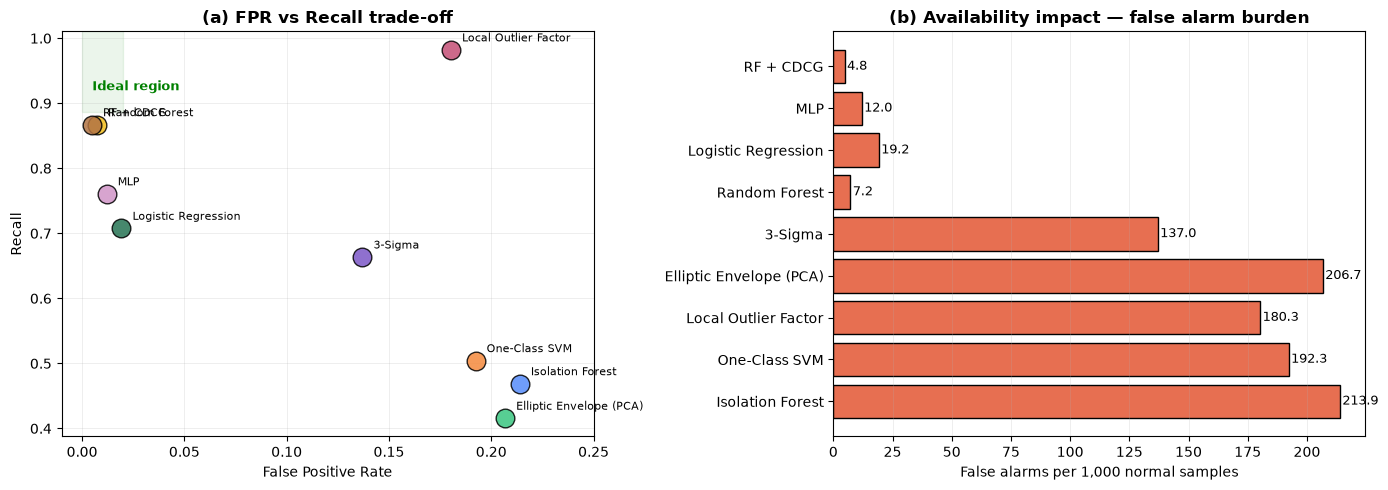

✓ Figure 9 saved


In [54]:
# ============================================================
# FIGURE 9: FPR VS RECALL + AVAILABILITY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) FPR vs Recall scatter
ax = axes[0]
for r in real_results:
    ax.scatter(r['fpr'], r['recall'], s=180,
               edgecolor='black', zorder=3, alpha=0.85)
    ax.annotate(r['name'],
                (r['fpr'], r['recall']),
                textcoords='offset points', xytext=(8, 6), fontsize=8)
ax.axvspan(0, 0.02, ymin=0.8, ymax=1, alpha=0.08, color='green')
ax.text(0.005, 0.92, 'Ideal region', fontsize=9,
         color='green', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('Recall')
ax.set_title('(a) FPR vs Recall trade-off', fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim(-0.01, 0.25)

# (b) False alarms per 1000 samples
ax = axes[1]
names = [r['name'] for r in real_results]
fprs = [r['fpr'] for r in real_results]
fa_per_k = [f*1000 for f in fprs]
bars = ax.barh(names, fa_per_k, color='#E76F51', edgecolor='black')
for bar, v in zip(bars, fa_per_k):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=9)
ax.set_xlabel('False alarms per 1,000 normal samples')
ax.set_title('(b) Availability impact — false alarm burden',
             fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig9_fpr_availability.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 9 saved")

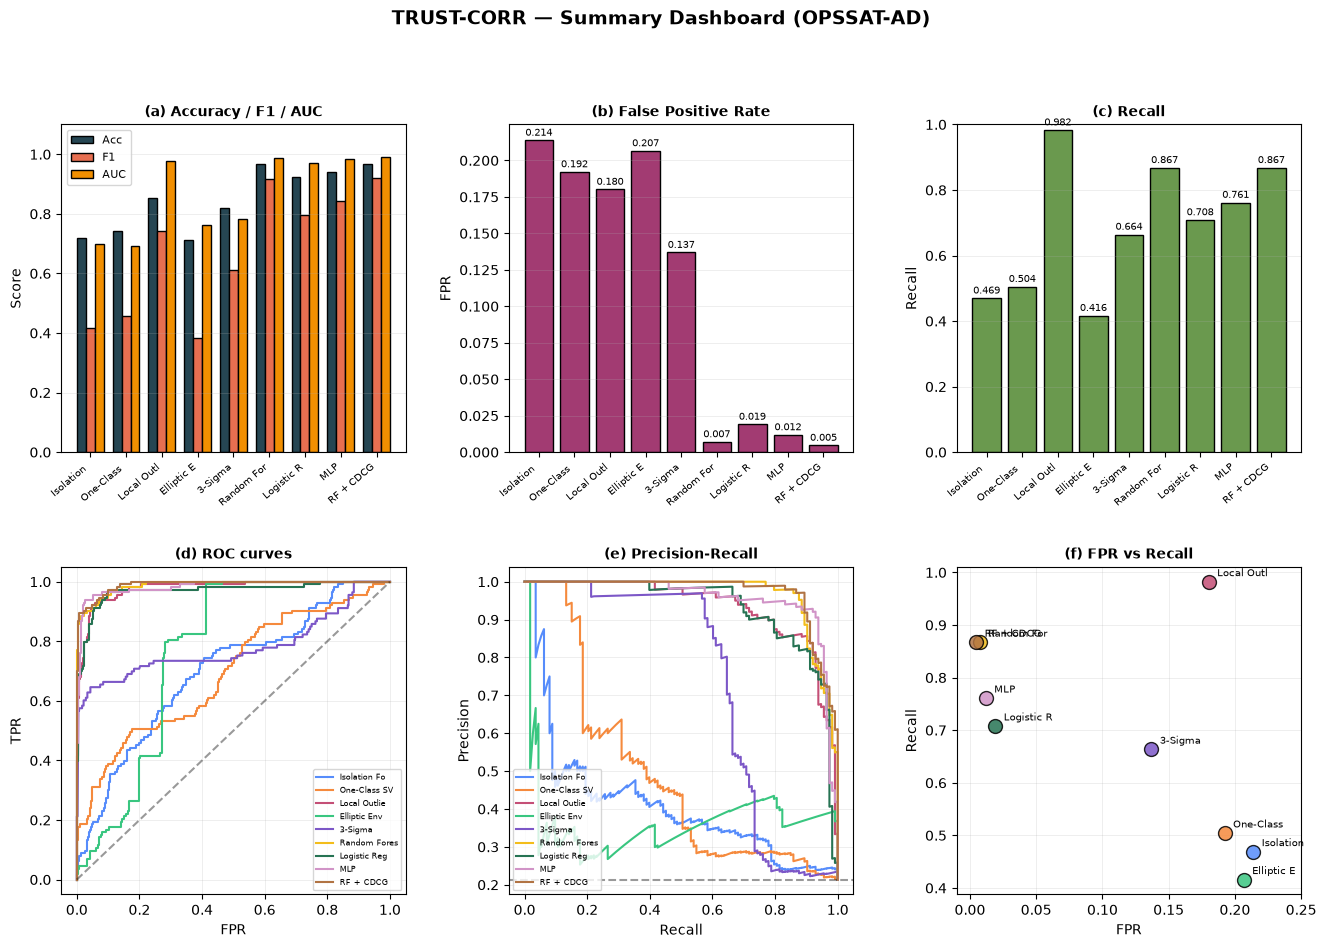

✓ Figure 10 saved


In [55]:
# ============================================================
# FIGURE 10: SUMMARY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.30)

# (a) Acc/F1/AUC
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(real_results))
w = 0.25
for i, (m, lab, c) in enumerate(zip(['accuracy','f1','auc'],
                                     ['Acc','F1','AUC'],
                                     ['#264653','#E76F51','#F18F01'])):
    vals = [r[m] if not np.isnan(r[m]) else 0 for r in real_results]
    ax.bar(x + i*w - w, vals, w, label=lab, color=c, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels([r['name'][:10] for r in real_results],
                    rotation=40, ha='right', fontsize=7)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('(a) Accuracy / F1 / AUC', fontweight='bold', fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# (b) FPR
ax = fig.add_subplot(gs[0, 1])
fprs = [r['fpr'] for r in real_results]
ax.bar(range(len(real_results)), fprs, color='#A23B72', edgecolor='black')
for i, v in enumerate(fprs):
    ax.text(i, v+0.003, f'{v:.3f}', ha='center', fontsize=7)
ax.set_xticks(range(len(real_results)))
ax.set_xticklabels([r['name'][:10] for r in real_results],
                    rotation=40, ha='right', fontsize=7)
ax.set_ylabel('FPR')
ax.set_title('(b) False Positive Rate', fontweight='bold', fontsize=10)
ax.grid(alpha=0.3, axis='y')

# (c) Recall
ax = fig.add_subplot(gs[0, 2])
recs = [r['recall'] for r in real_results]
ax.bar(range(len(real_results)), recs, color='#6A994E', edgecolor='black')
for i, v in enumerate(recs):
    ax.text(i, v+0.015, f'{v:.3f}', ha='center', fontsize=7)
ax.set_xticks(range(len(real_results)))
ax.set_xticklabels([r['name'][:10] for r in real_results],
                    rotation=40, ha='right', fontsize=7)
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.0)
ax.set_title('(c) Recall', fontweight='bold', fontsize=10)
ax.grid(alpha=0.3, axis='y')

# (d) ROC
ax = fig.add_subplot(gs[1, 0])
for r in real_results:
    if r['y_score'] is not None and not np.isnan(r['auc']):
        fpr_c, tpr_c, _ = roc_curve(y_test, r['y_score'])
        ax.plot(fpr_c, tpr_c, linewidth=1.5, label=f"{r['name'][:12]}")
ax.plot([0,1],[0,1], 'k--', alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('(d) ROC curves', fontweight='bold', fontsize=10)
ax.legend(fontsize=6, loc='lower right'); ax.grid(alpha=0.3)

# (e) PR
ax = fig.add_subplot(gs[1, 1])
for r in real_results:
    if r['y_score'] is not None:
        p_c, r_c, _ = precision_recall_curve(y_test, r['y_score'])
        ax.plot(r_c, p_c, linewidth=1.5, label=f"{r['name'][:12]}")
ax.axhline(y_test.mean(), color='k', ls='--', alpha=0.4)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('(e) Precision-Recall', fontweight='bold', fontsize=10)
ax.legend(fontsize=6, loc='lower left'); ax.grid(alpha=0.3)

# (f) FPR vs Recall
ax = fig.add_subplot(gs[1, 2])
for r in real_results:
    ax.scatter(r['fpr'], r['recall'], s=100,
                edgecolor='black', zorder=3, alpha=0.85)
    ax.annotate(r['name'][:10], (r['fpr'], r['recall']),
                textcoords='offset points', xytext=(6, 4), fontsize=7)
ax.set_xlabel('FPR'); ax.set_ylabel('Recall')
ax.set_title('(f) FPR vs Recall', fontweight='bold', fontsize=10)
ax.grid(alpha=0.3); ax.set_xlim(-0.01, 0.25)

plt.suptitle('TRUST-CORR — Summary Dashboard (OPSSAT-AD)',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 10 saved")

## Consolidated Results and Reproducibility Notes

The table and CSV below combine every detector from both pipelines (synthetic + OPS-SAT-AD) with a
single, consistent set of metrics (Accuracy, Precision, Recall, F1, False-Positive-Rate, MCC, AUC).
This is the table to paste into the *Experiments* / *Results* section of the interim and final
research papers.

**For the Phase 2 pitch video**, the most illustrative figures are:
- Figure 1 (simulator + injected anomalies) — shows the *problem* visually in ~10 seconds.
- Figure 2b (detection-by-family bar chart) — shows the rule-based *blind spot* motivating ML.
- Figure 3 or Figure 10 (dashboard) — shows the *real-data* benchmark result in one image.
- Figure 8 — shows the trust/graduated-response idea, which is the most novel contribution.

**Notes for the paper's Methodology section:**
- All unsupervised models are fit **only on nominal training data** — this is a hard requirement of
  the anomaly-detection setting and is checked explicitly (see `apply_isolation_forest`'s guard in
  the synthetic pipeline).
- The train/test split for OPS-SAT-AD is the dataset's **official chronological split**
  (`train` column), never randomised, to avoid leakage between segments of the same event.
- `contamination` / `nu` = 0.20 is fixed a priori from the *training* class balance, not tuned on
  test labels (see the comment in Block "Configuration").


In [60]:
# ============================================================
# TWO PIPELINES -TABLES COMPARAISON
# ============================================================

# -----------------------------
# 1. Synthetic Pipeline
# -----------------------------
synthetic_detectors = [
    res_rb,
    res_iso_sim,
    res_hybrid
]

synthetic_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_score'}
    for r in synthetic_detectors
])

print("=" * 110)
print("FINAL SUMMARY — SYNTHETIC PIPELINE")
print("=" * 110)

print(f"{'Model':<32} {'Acc':>7} {'Prec':>7} {'Rec':>7} "
      f"{'F1':>7} {'FPR':>7} {'MCC':>7} {'AUC':>7}")
print("-" * 110)

for r in synthetic_detectors:
    print(f"{r['name']:<32} "
          f"{r['accuracy']:>7.3f} {r['precision']:>7.3f} "
          f"{r['recall']:>7.3f} {r['f1']:>7.3f} "
          f"{r['fpr']:>7.3f} {r['mcc']:>7.3f} {r['auc']:>7.3f}")

print("=" * 110)

synthetic_summary.to_csv(
    os.path.join(OUTPUT_DIR, 'synthetic_results.csv'),
    index=False
)

print(f"\n✓ Synthetic results saved to {OUTPUT_DIR}/synthetic_results.csv")


# -----------------------------
# 2. OPS-SAT-AD Pipeline
# -----------------------------
ops_sat_detectors = [
    res_if,
    res_ocsvm,
    res_lof,
    res_ee,
    res_3sig,
    res_rf,
    res_lr,
    res_mlp,
    res_cdcg
]

ops_sat_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_score'}
    for r in ops_sat_detectors
])

print("\n" + "=" * 110)
print("FINAL SUMMARY — OPS-SAT-AD PIPELINE")
print("=" * 110)

print(f"{'Model':<32} {'Acc':>7} {'Prec':>7} {'Rec':>7} "
      f"{'F1':>7} {'FPR':>7} {'MCC':>7} {'AUC':>7}")
print("-" * 110)

for r in ops_sat_detectors:
    print(f"{r['name']:<32} "
          f"{r['accuracy']:>7.3f} {r['precision']:>7.3f} "
          f"{r['recall']:>7.3f} {r['f1']:>7.3f} "
          f"{r['fpr']:>7.3f} {r['mcc']:>7.3f} {r['auc']:>7.3f}")

print("=" * 110)

ops_sat_summary.to_csv(
    os.path.join(OUTPUT_DIR, 'ops_sat_results.csv'),
    index=False
)

print(f"\n✓ OPS-SAT-AD results saved to {OUTPUT_DIR}/ops_sat_results.csv")


# -----------------------------
# 3. Selected Models
# -----------------------------
print("\n" + "=" * 110)
print("SELECTED MODELS")
print("=" * 110)

print("Synthetic Pipeline : Hybrid Rule-Based + Isolation Forest")
print("OPS-SAT-AD Pipeline : Random Forest + CDCG")

FINAL SUMMARY — SYNTHETIC PIPELINE
Model                                Acc    Prec     Rec      F1     FPR     MCC     AUC
--------------------------------------------------------------------------------------------------------------
Rule-Based (synth.)                0.983   1.000   0.750   0.857   0.000   0.858     nan
Isolation Forest (synth.)          0.860   0.238   0.500   0.323   0.114   0.277   0.833
Hybrid (synth.)                    0.920   0.449   0.875   0.593   0.077   0.592     nan

✓ Synthetic results saved to outputs/synthetic_results.csv

FINAL SUMMARY — OPS-SAT-AD PIPELINE
Model                                Acc    Prec     Rec      F1     FPR     MCC     AUC
--------------------------------------------------------------------------------------------------------------
Isolation Forest                   0.718   0.373   0.469   0.416   0.214   0.236   0.698
One-Class SVM                      0.743   0.416   0.504   0.456   0.192   0.292   0.693
Local Outlier Factor   

# Final Summary

This work evaluated satellite anomaly detection through two complementary pipelines: a **Synthetic Pipeline** and a real-data **OPS-SAT-AD Pipeline**.

The **Synthetic Pipeline** provided a controlled environment for evaluating different anomaly types. The Hybrid approach, combining Rule-Based detection with Isolation Forest, achieved a recall of **0.875** and improved the detection of anomalies that could not be fully identified using fixed thresholds. It was therefore retained as the final approach for the synthetic experiments.

The **OPS-SAT-AD Pipeline** evaluated nine anomaly detection approaches using real satellite telemetry. Among the tested models, **Random Forest + CDCG** achieved the strongest overall results, with **96.8% accuracy, 98.0% precision, 86.7% recall, 92.0% F1-score, 0.5% false-positive rate, 0.903 MCC, and 0.990 AUC**.

The two pipelines are complementary: the synthetic pipeline enables controlled validation, while OPS-SAT-AD provides a realistic evaluation using real telemetry data. The final detection strategy combines **supervised detection for known anomaly patterns, unsupervised monitoring for abnormal behaviour, and trust-based graduated responses**.

Overall, the experiments demonstrate the potential of combining machine learning, feature engineering, and complementary detection mechanisms for reliable satellite telemetry anomaly detection.